In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


In [32]:
# Physical Parameters
E = 2e8
NU = 0.3
Lx = 1
Ly = 1
h = 0.004
q = 10    # [N/m^2]
D = E*h**3/(12*(1-NU**2))
Dnu = h**3/(12*(1-NU**2))

# Non-dimensionalization
L0 = Lx
w0 = q*(L0**4)/D
beta = Ly/Lx
q_bar = 1

# Hyperparameters
epochs = 3000
lr = 0.001
num_interior = 50
num_boundary = 100
lambda_bc = 10

In [ ]:
# Physical Parameters
E = 70e6
NU = 0.3
Lx = 0.1
Ly = 0.1
h = 1e-3
q = 10    # [N/m^2]
D = E*h**3/(12*(1-NU**2))
Dnu = h**3/(12*(1-NU**2))

# Non-dimensionalization
L0 = Lx
w0 = q*(L0**4)/D
beta = Ly/Lx
q_bar = 1

# Hyperparameters
epochs = 3000
lr = 0.001
num_interior = 50
num_boundary = 100
lambda_bc = 10

In [34]:
# 1. Neural Network Architecture
class EnergyPINN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, xy_in):
        output = self.network(xy_in)
        x = xy_in[:, 0:1]
        y = xy_in[:, 1:2]
        w = (x*y*(1-x)*(beta-y))**2* output[:, 0:1]
        return w

In [35]:
def grad(f, v):
    return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]

def get_rotatons(model, x, y):
    x.requires_grad_(True)
    y.requires_grad_(True)
    w = model(torch.cat([x, y], dim=1))
    w_x = grad(w, x)
    w_y = grad(w, y)
    return -w_x, -w_y

def get_curvatures(model, x, y):
    x.requires_grad_(True)
    y.requires_grad_(True)
    w = model(torch.cat([x, y], dim=1))
    w_x = grad(w, x)
    w_y = grad(w, y)
    w_xx = grad(w_x, x)
    w_yy = grad(w_y, y)
    w_xy = grad(w_x, y)
    kxx = -w_xx
    kyy = -w_yy
    kxy = -2 * w_xy
    return kxx, kyy, kxy

def get_moments(model, x, y):
    x.requires_grad_(True)
    y.requires_grad_(True)
    w = model(torch.cat([x, y], dim=1))
    w_x = grad(w, x)
    w_y = grad(w, y)
    w_xx = grad(w_x, x)
    w_yy = grad(w_y, y)
    w_xy = grad(w_x, y)
    kxx = -w_xx
    kyy = -w_yy
    kxy = -2 * w_xy
    mxx = (kxx + NU * kyy)
    myy = (kyy + NU * kxx)
    mxy = 0.5 * (1 - NU) * kxy
    return mxx, myy, mxy

In [36]:
def get_exactw(x, y, beta):
    w_exact = np.zeros_like(x)
    
    # Sum only odd terms (even terms are zero for uniform load)
    for m in range(1, 50, 2):
        for n in range(1, 50, 2):
            # Characteristic denominator for Kirchhoff biharmonic eqn
            # ((m*pi)^2 + (n*pi/beta)^2)^2
            denom = ( (m * np.pi)**2 + (n * np.pi / beta)**2 )**2
            
            # Fourier coefficient for uniform load q=1
            # Qmn = 16 / (pi^2 * m * n)
            coeff = 16 / ( (np.pi**6) * m * n * (m**2 + (n/beta)**2)**2 )
            
            # Basis functions
            term = coeff * np.sin(m * np.pi * x) * np.sin(n * np.pi * y / beta)
            w_exact += term
            
    return w_exact

In [37]:
# 2. Potential Energy Loss Function
def potential_energy_loss(model, x, y, bdr):
    # Enable gradient tracking
    x.requires_grad_(True)
    y.requires_grad_(True)
    
    # Forward pass
    w = model(torch.cat([x, y], dim=1))
    
    # Curvatures
    w_x = grad(w, x)
    w_y = grad(w, y)
    w_xx = grad(w_x, x)
    w_yy = grad(w_y, y)
    w_xy = grad(w_x, y)
    kxx = -w_xx
    kyy = -w_yy
    cxy = -2 *w_xy

    # Moments
    mxx = (kxx + NU * kyy)
    myy = (kyy + NU * kxx)
    mxy = 0.5 * (1 - NU) * cxy

    # Internal Strain Energy (U)
    # Area of domain is [0,1]x[0,beta]
    U = 0.5 * torch.mean(mxx*kxx + myy*kyy + mxy*cxy) * beta
    
    # External Potential (W) at Top Surface
    # Area of domain is [0,1]x[0,beta]
    W = torch.mean(q_bar * w)*beta

    return U - W

In [38]:
# Generate Points
# Interior (Collocation)
xc = torch.linspace(0, 1, num_interior)
yc = torch.linspace(0, beta, num_interior)
X, Y = torch.meshgrid(xc, yc, indexing='ij')
x_col = X.reshape(-1, 1)
y_col = Y.reshape(-1, 1)

# Boundary Points
t_bd = torch.linspace(0, 1, num_boundary).reshape(-1, 1)
o_bd = torch.ones(num_boundary, 1)  # contains only 1
z_bd = torch.zeros(num_boundary, 1) # contains only 0
bdr = [
    (o_bd, t_bd*beta), # right
    (t_bd, o_bd*beta), # top
    (z_bd, t_bd*beta), # left
    (t_bd, z_bd*beta), # bottom
]

model = EnergyPINN(2, 2, 40)
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training Loop
print("Starting training...")
previous_loss = float('inf')
loss_history = []

for epoch in range(epochs+1):
    optimizer.zero_grad()
    loss = potential_energy_loss(model, x_col, y_col, bdr)
    loss.backward()
    optimizer.step()
    
    current_loss = loss.item()
    loss_history.append(current_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Energy: {current_loss}")
    
    # Convergence Check: Relative Error
    if epoch > 0:
        relative_error = abs(previous_loss - current_loss) / abs(current_loss + 1e-15)
        if relative_error < 1e-20:
            print(f"Convergent at epoch {epoch}. Relative error: {relative_error}")
            break
    
    previous_loss = current_loss

Starting training...
Epoch 0 | Energy: -9.503884939476848e-05
Epoch 500 | Energy: -0.00016816859715618193
Epoch 1000 | Energy: -0.00016992187011055648
Epoch 1500 | Energy: -0.00017058967205230147
Convergent at epoch 1632. Relative error: 0.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


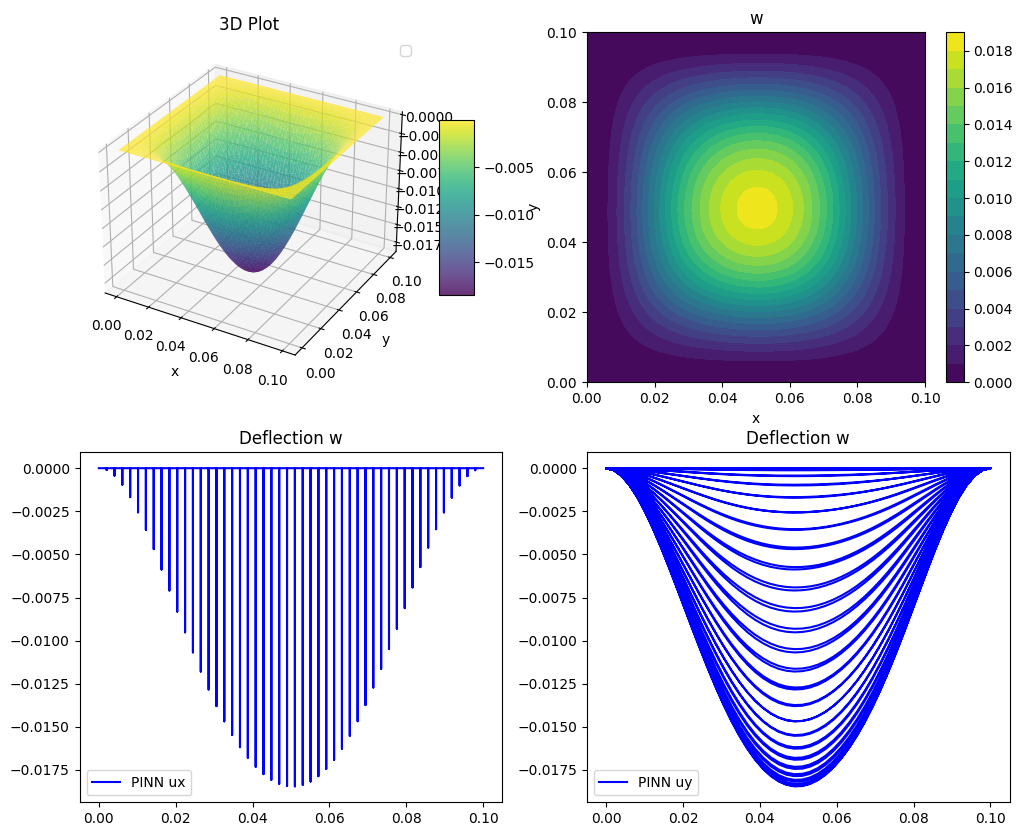

In [39]:
# 4. Visualization
with torch.no_grad():
    w_pred_2d = model(torch.cat([x_col, y_col], dim=1)).reshape(num_interior, num_interior).numpy()

X_1d = x_col.detach().numpy().flatten()*L0
Y_1d = y_col.detach().numpy().flatten()*L0
w_1d = w_pred_2d.flatten()*w0

X_2d = X.numpy()*L0
Y_2d = Y.numpy()*L0
w_2d = w_pred_2d*w0

# exact_x = 0.5
# exact_y = 0.5
# exact_w = 0.0107
    
plt.figure(figsize=(12, 10))
ax = plt.subplot(2, 2, 1, projection='3d')
surf=ax.plot_trisurf(X_1d, Y_1d, -w_1d, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title('3D Plot')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("w")
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.legend()

plt.subplot(2, 2, 2)
plt.title("w")
plt.xlabel("x")
plt.ylabel("y")
plt.contourf(X_2d, Y_2d, w_2d, levels=20)
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("Deflection w")
plt.plot(X_1d, -w_1d, color='blue', label='PINN ux')
# plt.plot(exact_x, -exact_w, 'ko', label='Exact w')
plt.legend()

plt.subplot(2, 2, 4)
plt.title("Deflection w")
plt.plot(Y_1d, -w_1d, color='blue', label='PINN uy')
# plt.plot(exact_y, -exact_w, 'ko', label='Exact w')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


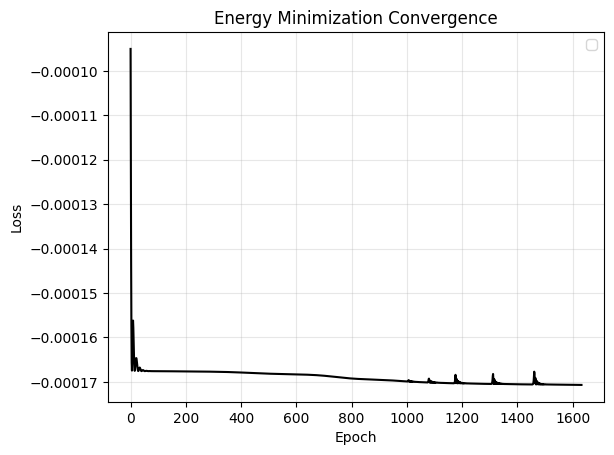

In [40]:
plt.plot(loss_history, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Energy Minimization Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()